# THIS IS A WORK IN PROGRESS

# FloodNet: NYC Street Flooding EDA

Date: 10/06/2026

In this exploratory data analysis, we'll look at street flooding event records detected by FloodNet sensors installed in flood prone areas across New York City. FloodNet NYC is a university/city agency consortium tasked with installing 500 flood sensors across the city's five boroughs by mid 2027, primarily funded by the New York City Department of Environmental Protection (NYC DEP). FloodNet sensors use ultrasonic pulses to measure the distance from their mounting position to the horizontal surface below the sensor at a regular interval, currently once every 60 seconds. A flood event is defined as a series of water depth measurements greater than 10 mm.

Two datasets are used in the analysis:

* [FloodNet: Street Flooding Events Measure by FloodNet Sensors](https://data.cityofnewyork.us/Environment/FloodNet-Street-Flooding-Events-Measured-by-FloodN/aq7i-eu5q/about_data): This dataset contains flood event records detected by FloodNet sensors, including the details for each event such as start time, end time, duration, and maximum recorded water depth. 
* [FloodNet: Sensor Deployment Metadata](https://data.cityofnewyork.us/Environment/FloodNet-Sensor-Deployment-Metadata/kb2e-tjy3/about_data): This dataset provides information about each FloodNet sensor including its location. 

Both datasets are free to download from the [NYC Open Data](https://www.nyc.gov/opendata) website.

More information on the FloodNet (New York University and The City University of New York) project can be found here: [https://www.floodnet.nyc](https://www.floodnet.nyc)



## Questions:

• How long does a flooding event typically last?

• What is the depth of a typical flood?

• How quickly do flooding events reach their maximum flood depth?

• How long does it take for a typical flood to drain? Do certain areas of the city see more standing water than others?

• How many events does an individual sensor detect in a year? month?

• Have all sensors detected at least 1 flooding event?

• Is there a seasoonality to flooding events? In which months do floods occur?

• How frequent do sensors with tidal influence detect flooding events compared to those without?

## Install Python Packages

In [529]:
import os
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from utils import iqr


## Configuration

In [530]:
# set pandas display optionns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 30)

In [531]:
# set visualization theme
sns.set_theme(context="notebook", style="whitegrid", palette="tab10")


## Load and Prepare data

In [532]:
# Read data from csv files
FLOODNET_METADATA_PATH = Path("../data/FloodNet__Sensor_Deployment_Metadata_20261006.csv")
FLOODNET_EVENTS_PATH = Path("../data/FloodNet__Street_Flooding_Events_Measured_by_FloodNet_Sensors_20261006.csv")

In [533]:
# Load csv data into pandas dataframes
df_metadata = pd.read_csv(FLOODNET_METADATA_PATH, parse_dates=["Date Installed", "Date Removed"])
df_events = pd.read_csv(FLOODNET_EVENTS_PATH, parse_dates=["Flood Start Datetime (GMT)", "Flood End Datetime (GMT)"], date_format="%m/%d/%Y %I:%M:%S %p")

In [534]:
# convert 'Tidally Influenced' from yes/no to bool
df_metadata['Tidally Influenced'] = df_metadata['Tidally Influenced'].map({"No": False, "Yes": True})
# Sensors with missing 'Date Removed' data are considered to be deployed, a date value signals a sensor has been retired 
df_metadata['Deployed'] = df_metadata['Date Removed'].isnull()

In [535]:
df_metadata['Date Installed Year'] = df_metadata['Date Installed'].dt.year

In [536]:
# Convert timezone for flood start and end times from GMT (UTC) to Eastern (America/New_York).
df_events["Flood Start Datetime (America/New_York)"] = pd.to_datetime(df_events["Flood Start Datetime (GMT)"], utc=True).dt.tz_convert('America/New_York')
df_events["Flood End Datetime (America/New_York)"] = pd.to_datetime(df_events["Flood End Datetime (GMT)"], utc=True).dt.tz_convert('America/New_York')
df_events["Flood Start Month"] = df_events["Flood Start Datetime (America/New_York)"].dt.month
df_events["Flood Start Year"] = df_events["Flood Start Datetime (America/New_York)"].dt.year

In [537]:
# Remove all commas from floats
float_columns = ['Time to Maximum Flood Depth (minutes)', 'Time to Drain From Peak (minutes)', 'Total Duration (minutes)',
                 'Duration of Flooding Greater Than 4 Inches (minutes)', 'Duration of Flooding Greater Than 12 Inches (minutes)',
                 'Duration of Flooding Greater Than 24 Inches (minutes)']
df_events[float_columns] = df_events[float_columns].replace(",", "", regex=True)

In [538]:
df_events['Time to Maximum Flood Depth (minutes)'] = df_events['Time to Maximum Flood Depth (minutes)'].astype(np.float64)
df_events['Time to Drain From Peak (minutes)'] = df_events['Time to Drain From Peak (minutes)'].astype(np.float64)
df_events['Total Duration (minutes)'] = df_events['Total Duration (minutes)'].astype(np.float64)
df_events['Duration of Flooding Greater Than 4 Inches (minutes)'] = df_events['Duration of Flooding Greater Than 4 Inches (minutes)'].astype(np.float64)
df_events['Duration of Flooding Greater Than 12 Inches (minutes)'] = df_events['Duration of Flooding Greater Than 12 Inches (minutes)'].astype(np.float64)
df_events['Duration of Flooding Greater Than 24 Inches (minutes)'] = df_events['Duration of Flooding Greater Than 24 Inches (minutes)'].astype(np.float64)

In [539]:
# convert time series data from string (json list) to numpy array
df_events['Time Series Depth Values (inches)'] = df_events['Time Series Depth Values (inches)'].str.strip("[]").str.split(", ").apply(lambda x: np.array([float(i) for i in x], dtype=np.float64))
df_events['Time Series Depth Timestamps (seconds)'] = df_events['Time Series Depth Timestamps (seconds)'].str.strip("[]").str.split(", ").apply(lambda x: np.array([int(i) for i in x], dtype=np.uint))

In [540]:
df_metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 18 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   Sensor Name                                          491 non-null    str           
 1   Sensor ID                                            491 non-null    str           
 2   Date Installed                                       491 non-null    datetime64[us]
 3   Tidally Influenced                                   491 non-null    bool          
 4   Date Removed                                         43 non-null     datetime64[us]
 5   Street Name                                          491 non-null    str           
 6   Borough                                              491 non-null    str           
 7   Zipcode                                              491 non-null    int64         
 8   CommunityBo

In [541]:
df_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 3422 entries, 0 to 3421
Data columns (total 17 columns):
 #   Column                                                 Non-Null Count  Dtype                           
---  ------                                                 --------------  -----                           
 0   Sensor Name                                            3422 non-null   str                             
 1   Sensor ID                                              3422 non-null   str                             
 2   Flood Start Datetime (GMT)                             3422 non-null   datetime64[us]                  
 3   Flood End Datetime (GMT)                               3422 non-null   datetime64[us]                  
 4   Maximum Flood Depth (inches)                           3422 non-null   float64                         
 5   Time to Maximum Flood Depth (minutes)                  3422 non-null   float64                         
 6   Time to Drain From Peak (mi

In [542]:
df_events[df_events['Time to Drain From Peak (minutes)'].isnull()]

,Sensor Name,Sensor ID,Flood Start Datetime (GMT),Flood End Datetime (GMT),Maximum Flood Depth (inches),Time to Maximum Flood Depth (minutes),Time to Drain From Peak (minutes),Total Duration (minutes),Duration of Flooding Greater Than 4 Inches (minutes),Duration of Flooding Greater Than 12 Inches (minutes),Duration of Flooding Greater Than 24 Inches (minutes),Time Series Depth Values (inches),Time Series Depth Timestamps (seconds),Flood Start Datetime (America/New_York),Flood End Datetime (America/New_York),Flood Start Month,Flood Start Year
3312,BK - Hoyt St/5th St,BK-hoyt-st-5th-st-007sk0,2023-09-29 07:23:34,2023-09-29 20:55:52,9.25,1579176.5,NaN,812.31,0.0,0.0,0.0,"[0.0, 0.79, 0.75, 1.26, 1....","[0, 63, 126, 252, 314, 378...",2023-09-29 03:23:34-04:00,2023-09-29 16:55:52-04:00,9,2023


In [543]:
# join the two dataframes together on 'Sensor ID'
df = pd.merge(left=df_events, right=df_metadata, how="left", on="Sensor ID", suffixes=("_Event", "_Metadata"))
df.head()

,Sensor Name_Event,Sensor ID,Flood Start Datetime (GMT),Flood End Datetime (GMT),Maximum Flood Depth (inches),Time to Maximum Flood Depth (minutes),Time to Drain From Peak (minutes),Total Duration (minutes),Duration of Flooding Greater Than 4 Inches (minutes),Duration of Flooding Greater Than 12 Inches (minutes),Duration of Flooding Greater Than 24 Inches (minutes),Time Series Depth Values (inches),Time Series Depth Timestamps (seconds),Flood Start Datetime (America/New_York),Flood End Datetime (America/New_York),Flood Start Month,Flood Start Year,Sensor Name_Metadata,Date Installed,Tidally Influenced,Date Removed,Street Name,Borough,Zipcode,CommunityBoard,Council District,Census Tract 2020,NTA,Latitude,Longitude,Sensor Ground Height Above Local Low Point (inches),Sensor Location,Deployed,Date Installed Year
0,Q - Beach 84 St,Q-beach-84-st-0me680,2023-10-30 12:00:39,2023-10-30 16:38:19,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"[0.0, 0.87, 1.02, 1.38, 1....","[0, 1008, 1134, 1512, 1826...",2023-10-30 08:00:39-04:00,2023-10-30 12:38:19-04:00,10,2023,Q - Beach 84 St,2021-12-10,True,NaT,Beach 84th Street,Queens,11693,414,QN14,4094202,QN1402,40.591360,-73.809960,8.27,POINT (-73.80996 40.59136),True,2021
1,BX - 1st St/Avenue A,BX-1st-st-avenue-a-1zby90,2025-04-26 23:17:20,2025-04-27 11:55:34,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"[0.0, 0.71, 1.38, 1.38, 1....","[0, 64, 129, 132, 196, 260...",2025-04-26 19:17:20-04:00,2025-04-27 07:55:34-04:00,4,2025,BX - 1st St/Avenue A,2024-07-18,False,NaT,Avenue A,Bronx,10474,202,BX02,2011702,BX0201,40.812851,-73.881043,3.62,POINT (-73.881043 40.812851),True,2024
2,Q - Beach 35 St/Beach Chan...,Q-beach-35-st-beach-channe...,2024-02-09 11:41:01,2024-02-09 13:20:57,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"[0.0, 0.43, 0.63, 0.71, 0....","[0, 68, 136, 204, 273, 341...",2024-02-09 06:41:01-05:00,2024-02-09 08:20:57-05:00,2,2024,Q - Beach 35 St/Beach Chan...,2023-12-19,True,NaT,Beach 35th Street,Queens,11691,414,QN14,4099200,QN1401,40.596618,-73.767808,6.97,POINT (-73.767808 40.596618),True,2023
3,BX - Tibbett Ave/W 234th St,BX-w-234th-st-tibbett-ave-...,2025-08-20 21:05:19,2025-08-21 00:46:19,1.18,80.00,141.00,221.00,0.00,0.0,0.0,"[0.0, 0.43, 0.47, 0.47, 0....","[0, 60, 120, 180, 240, 300...",2025-08-20 17:05:19-04:00,2025-08-20 20:46:19-04:00,8,2025,BX - Tibbett Ave/W 234th St,2025-03-27,False,NaT,Tibbett Avenue,Bronx,10463,208,BX08,2028700,BX0802,40.883260,-73.905850,4.09,POINT (-73.90585 40.88326),True,2025
4,Q - Davenport Ct 1,Q-davenport-ct-1-07zks0,2024-01-10 00:39:25,2024-01-10 02:30:40,2.09,59.82,51.43,111.25,0.00,0.0,0.0,"[0.0, 0.47, 0.47, 0.43, 0....","[0, 63, 127, 189, 252, 315...",2024-01-09 19:39:25-05:00,2024-01-09 21:30:40-05:00,1,2024,Q - Davenport Ct 1,2021-03-05,True,NaT,Davenport Court,Queens,11414,410,QN10,4088400,QN1003,40.653387,-73.830559,6.97,POINT (-73.830559 40.653387),True,2021


## FloodNet Sensor Analysis

### Deployed

How many FloodNet sensors are currently deployed versus sensors that have been retired?

In [544]:
df_metadata['Deployed'].value_counts()

Deployed
True     448
False     43
Name: count, dtype: int64

### Date Installed

In what year were FloodNet sensors installed? `Date Installed` gives us the date that the sensor was installed at its location. We've extracted the year into `Date Installed Year`.

In [545]:
# When were FloodNet sensors installed?
df_metadata['Date Installed Year'].value_counts()

Date Installed Year
2024    162
2026    129
2025    106
2023     60
2022     20
2021     12
2020      2
Name: count, dtype: int64

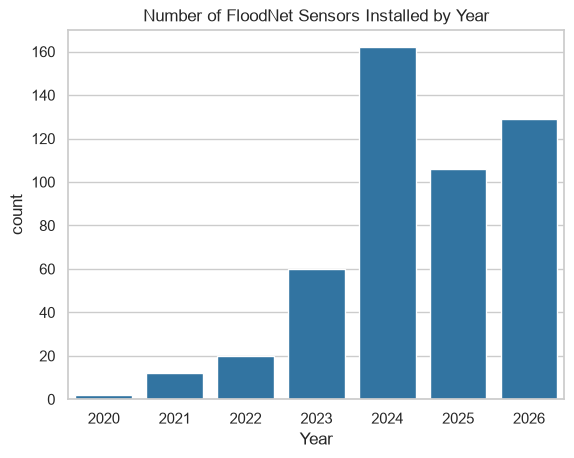

In [546]:
plt.figure()
plt.title("Number of FloodNet Sensors Installed by Year")
sns.countplot(data=df_metadata, x='Date Installed Year')
plt.xlabel("Year")
plt.show()

In [547]:
# find the sensors that were the first to be deployed
first_installed_floodnet_sensors = df_metadata[df_metadata['Date Installed'] == df_metadata['Date Installed'].min()]
first_installed_floodnet_sensors

,Sensor Name,Sensor ID,Date Installed,Tidally Influenced,Date Removed,Street Name,Borough,Zipcode,CommunityBoard,Council District,Census Tract 2020,NTA,Latitude,Longitude,Sensor Ground Height Above Local Low Point (inches),Sensor Location,Deployed,Date Installed Year
146,BK - Hoyt St/5th St,BK-hoyt-st-5th-st-007sk0,2020-10-05,False,NaT,Hoyt Street,Brooklyn,11231,306,BK06,3007700,BK0601,40.676672,-73.994591,12.24,POINT (-73.994591 40.676672),True,2020
459,BK - Marcy Ave/Ellery St,BK-marcy-av-ellery-st-007vc0,2020-10-05,False,2023-03-09,Marcy Avenue,Brooklyn,11206,303,BK03,3025500,BK0301,40.697974,-73.949837,20.87,POINT (-73.949837 40.697974),False,2020


In [548]:
print(f"The first {first_installed_floodnet_sensors.shape[0]} FloodNet sensors were installed on {first_installed_floodnet_sensors['Date Installed'].iloc[0].date()}")

The first 2 FloodNet sensors were installed on 2020-10-05


### Borough

How are the sensors distributed throughout the boroughs? `Borough` shows us which borough the sensor is installed in.

In [549]:
df_metadata['Borough'].value_counts(normalize=True)

Borough
Queens           0.336049
Brooklyn         0.315682
Bronx            0.146640
Manhattan        0.107943
Staten Island    0.093686
Name: proportion, dtype: float64

In [550]:
# How many FloodNet sensors were installed in each borough by year?
borough_counts_by_year = df_metadata.groupby('Date Installed Year')['Borough'].value_counts(normalize=False)
borough_counts_by_year

Date Installed Year  Borough      
2020                 Brooklyn          2
2021                 Queens            5
                     Brooklyn          4
                     Manhattan         3
2022                 Brooklyn          6
                     Queens            5
                     Bronx             4
                     Staten Island     3
                     Manhattan         2
2023                 Queens           23
                     Brooklyn         19
                     Staten Island    11
                     Bronx             6
                     Manhattan         1
2024                 Queens           61
                     Brooklyn         49
                     Manhattan        24
                     Bronx            18
                     Staten Island    10
2025                 Bronx            32
                     Queens           27
                     Brooklyn         25
                     Manhattan        15
                     S

In [551]:
borough_ranks_history = []
min_year = borough_counts_by_year.index.get_level_values('Date Installed Year').min()
max_year = borough_counts_by_year.index.get_level_values('Date Installed Year').max()
for year in range(min_year, max_year + 1):
    borough_ranks_series = borough_counts_by_year[year].rank(ascending=False)
    # rename the series to the year for easier merging later
    borough_ranks_series.name = year
    borough_ranks_history.append(borough_ranks_series)
# merge the list of series into a single dataframe
borough_ranks_history_df = pd.concat(borough_ranks_history, axis=1)
borough_ranks_history_df.rename(columns={'Date Installed Year': 'year'}, inplace=True)
borough_ranks_history_df  

,2020,2021,2022,2023,2024,2025,2026
Borough,,,,,,,
Brooklyn,1.0,2.0,1.0,2.0,2.0,3.0,1.0
Queens,NaN,1.0,2.0,1.0,1.0,2.0,2.0
Manhattan,NaN,3.0,5.0,5.0,3.0,4.0,5.0
Bronx,NaN,NaN,3.0,4.0,4.0,1.0,4.0
Staten Island,NaN,NaN,4.0,3.0,5.0,5.0,3.0


In [552]:
daily_install_counts_by_borough = df_metadata.groupby(['Date Installed', 'Borough'])['Sensor ID'].count().unstack().fillna(0.0)
daily_install_counts_by_borough.head()

Borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island
Date Installed,,,,,
2020-10-05,0.0,2.0,0.0,0.0,0.0
2021-03-05,0.0,0.0,0.0,4.0,0.0
2021-07-15,0.0,2.0,0.0,0.0,0.0
2021-07-16,0.0,1.0,0.0,0.0,0.0
2021-12-10,0.0,0.0,0.0,1.0,0.0


In [553]:
daily_install_date_range = pd.date_range(df_metadata['Date Installed'].min(), df_metadata['Date Installed'].max(), freq='D')

In [554]:
daily_install_counts_time_series_df = pd.DataFrame(index=daily_install_date_range, data=daily_install_counts_by_borough).fillna(0.0)
daily_install_counts_time_series_df.head()

Borough,Bronx,Brooklyn,Manhattan,Queens,Staten Island
2020-10-05,0.0,2.0,0.0,0.0,0.0
2020-10-06,0.0,0.0,0.0,0.0,0.0
2020-10-07,0.0,0.0,0.0,0.0,0.0
2020-10-08,0.0,0.0,0.0,0.0,0.0
2020-10-09,0.0,0.0,0.0,0.0,0.0


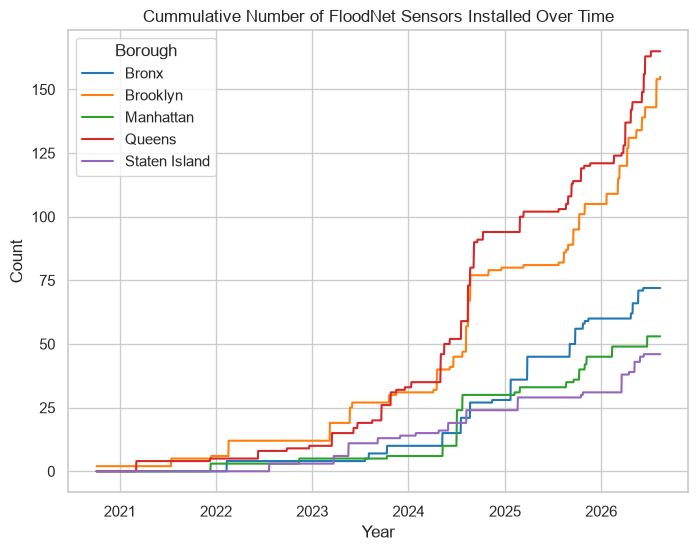

In [555]:
plt.figure(figsize=(8, 6))
plt.title("Cummulative Number of FloodNet Sensors Installed Over Time")
sns.lineplot(data=daily_install_counts_time_series_df.cumsum(), dashes=None)
plt.ylabel("Count")
plt.xlabel("Year")
plt.show()

In [556]:
# def prepare_time_series_df(data_frame):
#     # group the data by `date` and count number of workouts
#     daily_counts = data_frame.groupby(data_frame['Date'])[['ID']].count()
#     # group the data by `date` and calculate the sum of workout `time`
#     daily_duration = data_frame.groupby(data_frame['Date'])[['Time']].sum()
#     # group the data by `date` and workout `type` and calculate the sum of workout `time` by workout `type`
#     daily_dur_type = data_frame.groupby([data_frame['Date'], 'Type'])['Time'].sum().unstack().fillna(0.0)
#     # merge daily_counts and daily_duration into a dataframe
#     daily_stats = pd.merge(daily_counts, daily_duration, left_index=True, right_index=True)
#     # rename the columns of the merged dataframe daily_stats
#     daily_stats.columns = ['Counts', 'Overall Time']
#     # merge daily_stats with daily_dur_type into a dataframe
#     daily_stats = pd.merge(daily_stats, daily_dur_type, left_index=True, right_index=True)
#     # prepare a DateTimeIndex using pandas date_range with the data's minimun date and today's day
#     date_range = pd.date_range(data_frame.Date.min(), today, freq='D')
#     # create a new dataframe with date_range as the index and daily_stats the data, fill any missing values with 0.0
#     time_series_df = pd.DataFrame(index=date_range, data=daily_stats).fillna(0.0)
#     # group the data by date and calculate the mean of `feeling`, save to a dataframe with date_range DateTimeIndex
#     feeling = pd.DataFrame(index=date_range, data=df.groupby('Date')['Feeling'].mean()).ffill()
#     # add `feeling` to time_series_df and fill missing values with 0.0
#     time_series_df['Feeling'] = feeling

#     return time_series_df

### Tidally Influenced

How many FloodNet sensors are influenced by tides? `Tidally Influenced` indicates whether the water levels being recorded at the sensor are affected by the regular rise and fall of tides in nearby tidal waters.

In [557]:
df_metadata['Tidally Influenced'].value_counts()

Tidally Influenced
False    424
True      67
Name: count, dtype: int64

## Flooding Events Analysis

### Flooding Event Counts

Have all FloodNet sensors detected at least 1 flooding event?

In [558]:
merged_metadata_events = df_metadata[['Sensor ID']].merge(df_events[['Sensor ID', 'Flood Start Datetime (America/New_York)']], on="Sensor ID", how="left")
flood_event_counts_per_sensor = merged_metadata_events.groupby('Sensor ID')['Flood Start Datetime (America/New_York)'].count().reset_index()
flood_event_counts_per_sensor = flood_event_counts_per_sensor.rename(columns={"Flood Start Datetime (America/New_York)": "Flood Event Count"})

In [559]:
flood_event_counts_per_sensor.sort_values(by="Flood Event Count", ascending=False).head(25)

,Sensor ID,Flood Event Count
379,Q-beach-84-st-0me680,469
173,BX-ditmars-st-hunter-ave-1...,381
429,Q-russell-st-1-07zqc0,153
390,Q-brookville-blvd-rockaway...,126
380,Q-beach-84th-st-beach-chan...,110
389,Q-brookville-blvd-149th-av...,90
400,Q-davenport-ct-1-07zks0,79
368,Q-beach-35-st-beach-channe...,76
303,Q-161st-ave-99th-st-1a5q80,76
279,Q-102nd-st-160th-ave-1a5ng0,72


In [560]:
flood_event_counts_by_sensor_counts = flood_event_counts_per_sensor['Flood Event Count'].value_counts().to_frame().rename(columns={"count": "Sensor Count"})
flood_event_counts_by_sensor_counts.head(10)

,Sensor Count
Flood Event Count,
0,173
1,72
2,57
3,53
4,25
5,16
6,12
7,12
8,12


In [561]:
print(f"{flood_event_counts_by_sensor_counts.loc[0]['Sensor Count']} FloodNet sensors have detected {flood_event_counts_by_sensor_counts.loc[0].name} flooding events.")

173 FloodNet sensors have detected 0 flooding events.


### Seasonality

Is there a seasonality to flooding events? In which months do floods occur?

In [562]:
flood_event_counts_by_month = df['Flood Start Month'].value_counts(normalize=True).sort_index()
flood_event_counts_by_month

Flood Start Month
1     0.030976
2     0.031853
3     0.099065
4     0.068381
5     0.090883
6     0.065751
7     0.136470
8     0.189363
9     0.135593
10    0.082116
11    0.033606
12    0.035944
Name: proportion, dtype: float64

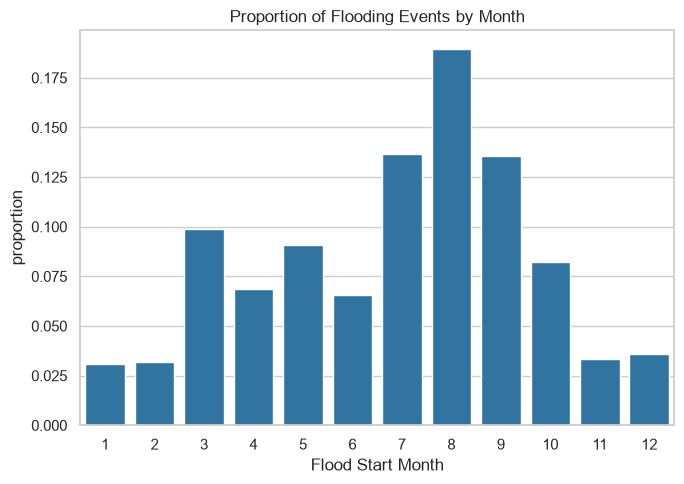

In [563]:
plt.figure(figsize=(7,5))
plt.title("Proportion of Flooding Events by Month")
sns.barplot(flood_event_counts_by_month)
plt.tight_layout()
plt.show()

### Flood Depth

What is the depth of a typical flood? We can see the maximum flood depth (in inches) measured at the sensor location during an event by looking at `Maximum Flood Depth (inches)`.

In [564]:
df['Maximum Flood Depth (inches)'].describe()

count    3422.000000
mean        5.085082
std         5.155282
min         0.430000
25%         1.650000
50%         3.480000
75%         6.540000
max        46.140000
Name: Maximum Flood Depth (inches), dtype: float64

In [565]:
average_max_flood_depth = np.round(df['Maximum Flood Depth (inches)'].mean(), 2)
max_flood_depth = np.round(df['Maximum Flood Depth (inches)'].max(), 2)

In [566]:
print(f"On average, a flooding event had a maximum depth of {average_max_flood_depth} inches")
print(f"The maximum depth of a flooding event was {max_flood_depth} inches ({int(max_flood_depth // 12)} feet {max_flood_depth % 12} inches)")

On average, a flooding event had a maximum depth of 5.09 inches
The maximum depth of a flooding event was 46.14 inches (3 feet 10.14 inches)


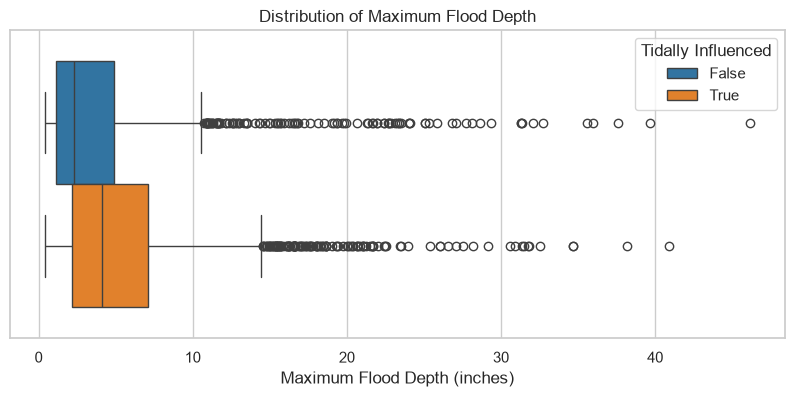

In [567]:
plt.figure(figsize=(10,4))
plt.title("Distribution of Maximum Flood Depth")
sns.boxplot(data=df, x='Maximum Flood Depth (inches)', hue='Tidally Influenced', hue_order=[False, True])
plt.show()

In [568]:
df.groupby('Tidally Influenced')['Maximum Flood Depth (inches)'].mean()

Tidally Influenced
False    4.311988
True     5.469768
Name: Maximum Flood Depth (inches), dtype: float64

### Flood Duration

How long do flooding events last? Let's look at `Total Duration (minutes)` to see the total duration of flood events in minutes. 

In [569]:
df['Total Duration (minutes)'].describe()

count    3422.000000
mean      153.221543
std       223.892731
min         5.000000
25%        46.295000
50%       110.000000
75%       187.355000
max      4542.910000
Name: Total Duration (minutes), dtype: float64

In [570]:
average_flood_duration = np.round(df['Total Duration (minutes)'].mean(), 2)
max_flood_duration = np.round(df['Total Duration (minutes)'].max(), 2)

In [571]:
print(f"On average, flooding events lasted {average_flood_duration} minutes ({int(average_flood_duration // 60)} hours and {average_flood_duration % 60} minutes)")
print(f"The longest a flooding event lasted was {max_flood_duration} minutes ({int(max_flood_duration // (24 * 60))} days {int(max_flood_duration % (24 * 60) // 60)} hours and {max_flood_duration % 60:.2f} minutes)")

On average, flooding events lasted 153.22 minutes (2 hours and 33.22 minutes)
The longest a flooding event lasted was 4542.91 minutes (3 days 3 hours and 42.91 minutes)


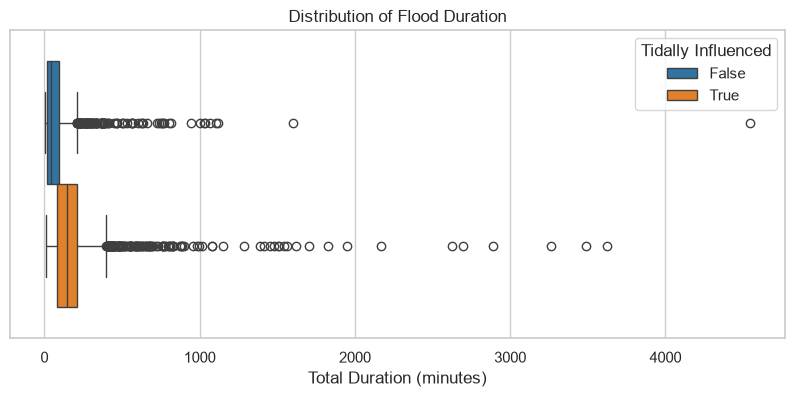

In [572]:
plt.figure(figsize=(10,4))
plt.title("Distribution of Flood Duration")
sns.boxplot(data=df, x='Total Duration (minutes)', hue='Tidally Influenced', hue_order=[False, True], showfliers=True)
plt.show()

In [573]:
df.groupby('Tidally Influenced')['Total Duration (minutes)'].mean()

Tidally Influenced
False     92.086095
True     183.642114
Name: Total Duration (minutes), dtype: float64

### Time to Max Flood Depth

How quickly do flooding events reach their maximum flood depth? `Time to Maximum Flood Depth (minutes)` records the time in minutes after the flood start time that it took for the flood to reach `Maximum Flood Depth (inches)`.

In [574]:
df['Time to Maximum Flood Depth (minutes)'].describe()

count    3.422000e+03
mean     5.182938e+02
std      2.699462e+04
min      0.000000e+00
25%      1.400000e+01
50%      3.598500e+01
75%      7.900750e+01
max      1.579176e+06
Name: Time to Maximum Flood Depth (minutes), dtype: float64

In [575]:
# df.loc[df['Time to Maximum Flood Depth (minutes)'].argmax()]

In [576]:
average_time_to_max_flood_depth = np.round(df['Time to Maximum Flood Depth (minutes)'].mean(), 2)
max_time_to_max_flood_depth = np.round(df['Time to Maximum Flood Depth (minutes)'].max(), 2)

In [577]:
print(f"On average, flooding events took {average_time_to_max_flood_depth} minutes ({int(average_time_to_max_flood_depth // 60)} hours and {average_time_to_max_flood_depth % 60:.2f} minutes) to reach maximum flood depth.")
print(f"The longest it took a flooding event to reach its maximum depth was {max_time_to_max_flood_depth} minutes ({int(max_time_to_max_flood_depth // (24 * 60))} days {int(max_time_to_max_flood_depth % (24 * 60) // 60)} hours and {max_time_to_max_flood_depth % 60} minutes)")

On average, flooding events took 518.29 minutes (8 hours and 38.29 minutes) to reach maximum flood depth.
The longest it took a flooding event to reach its maximum depth was 1579176.5 minutes (1096 days 15 hours and 36.5 minutes)


NOTE: 1579176.5 minutes as the maximum time to reach the maximum flood depth for a flooding event must be incorrect. Let's remove the outliers from `Time to Maximum Flood Depth (minutes)` and see how the average changes.

In [578]:
# remove outliers, get the indices of the iqr
IQR_idx = iqr.get_IQR(df.loc[:][['Time to Maximum Flood Depth (minutes)']])
# print(IQR_idx)

Found 129 outliers in variable Time to Maximum Flood Depth (minutes).
Removed 129 outliers from 3422 records, 3293 records remain.


In [579]:
df.loc[IQR_idx]['Time to Maximum Flood Depth (minutes)'].describe()

count    3293.000000
mean       46.710808
std        39.938099
min         0.000000
25%        13.110000
50%        34.000000
75%        73.990000
max       175.950000
Name: Time to Maximum Flood Depth (minutes), dtype: float64

In [580]:
average_time_to_max_flood_depth_iqr = np.round(df.loc[IQR_idx]['Time to Maximum Flood Depth (minutes)'].mean(), 2)
max_time_to_max_flood_depth_iqr = np.round(df.loc[IQR_idx]['Time to Maximum Flood Depth (minutes)'].max(), 2)

In [581]:
print(f"With outliers removed, flooding events took {average_time_to_max_flood_depth_iqr} minutes to reach maximum flood depth on average.")
print(f"After removing outliers, the longest it took a flooding event to reach its maximum depth was {max_time_to_max_flood_depth_iqr} minutes ({int(max_time_to_max_flood_depth_iqr % (24 * 60) // 60)} hours and {max_time_to_max_flood_depth_iqr % 60:.2f} minutes)")

With outliers removed, flooding events took 46.71 minutes to reach maximum flood depth on average.
After removing outliers, the longest it took a flooding event to reach its maximum depth was 175.95 minutes (2 hours and 55.95 minutes)


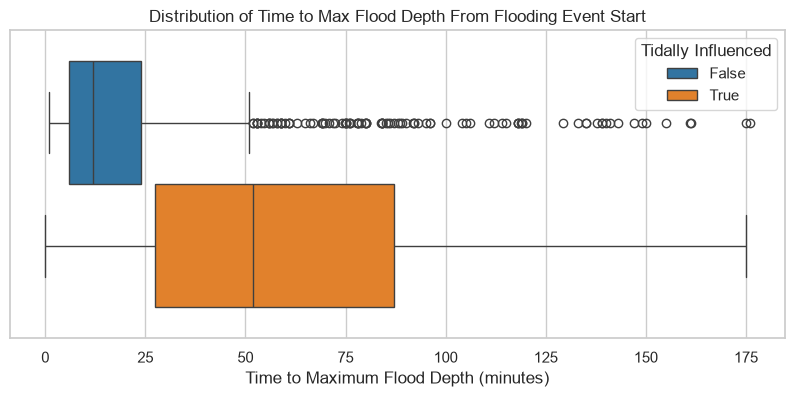

In [582]:
plt.figure(figsize=(10,4))
plt.title("Distribution of Time to Max Flood Depth From Flooding Event Start")
sns.boxplot(data=df.loc[IQR_idx], x='Time to Maximum Flood Depth (minutes)', hue='Tidally Influenced', hue_order=[False, True], showfliers=True)
plt.show()

In [583]:
df.loc[IQR_idx].groupby('Tidally Influenced')['Time to Maximum Flood Depth (minutes)'].mean()

Tidally Influenced
False    21.382275
True     59.624759
Name: Time to Maximum Flood Depth (minutes), dtype: float64

### Time to Drain

How long does it take for a flooding event to drain? `Time to Drain From Peak (minutes)` shows us the time in minutes it took for the flood to drain and reach 0 inches from the `Maximum Flood Depth (inches)`.

In [584]:
df['Time to Drain From Peak (minutes)'].describe()

count    3421.000000
mean       96.196291
std       176.136879
min         1.000000
25%        26.250000
50%        52.850000
75%       105.000000
max      3609.570000
Name: Time to Drain From Peak (minutes), dtype: float64

In [585]:
average_time_to_drain_from_peak = np.round(df.loc[IQR_idx]['Time to Drain From Peak (minutes)'].mean(), 2)
max_time_to_drain_from_peak = np.round(df.loc[IQR_idx]['Time to Drain From Peak (minutes)'].max(), 2)

In [586]:
print(f"On average, flooding events took {average_time_to_drain_from_peak} minutes ({int(average_time_to_drain_from_peak // 60)} hours and {average_time_to_drain_from_peak % 60} minutes) to drain from peak.")
print(f"The longest a flooding event took to drain from peak was {max_time_to_drain_from_peak} minutes ({int(max_time_to_drain_from_peak // (24 * 60))} days {int(max_time_to_drain_from_peak % (24 * 60) // 60)} hours and {max_time_to_drain_from_peak % 60:.2f} minutes)")

On average, flooding events took 88.03 minutes (1 hours and 28.03 minutes) to drain from peak.
The longest a flooding event took to drain from peak was 3609.57 minutes (2 days 12 hours and 9.57 minutes)


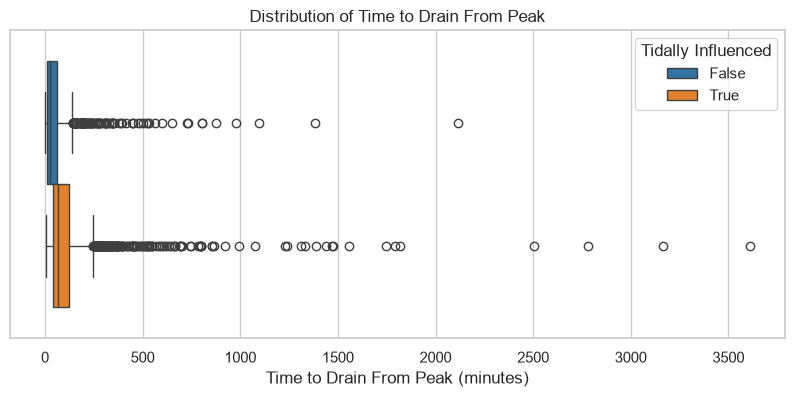

In [587]:
plt.figure(figsize=(10,4))
plt.title("Distribution of Time to Drain From Peak")
sns.boxplot(data=df, x='Time to Drain From Peak (minutes)', hue='Tidally Influenced', hue_order=[False, True], showfliers=True)
plt.show()

In [588]:
df.loc[IQR_idx].groupby('Tidally Influenced')['Time to Drain From Peak (minutes)'].mean()

Tidally Influenced
False     54.054469
True     105.353961
Name: Time to Drain From Peak (minutes), dtype: float64

## Latest Flooding Event

FloodNet sensors measure the distance from their mounting position to the surface below the sensor once every 60 seconds. Note: Some sensors operating before November 2021 were programmed to measure distance once every 5 minutes, therefore some data before November 2021 may be presented with a time interval > 1 minute. Additionally, occasional transmission issues and noise filtering processes to remove invalid measurements may result in some time series depth data with intervals > 1 minute.

In [606]:
latest_flood_event = df.sort_values(by=['Flood Start Datetime (America/New_York)'], ascending=False).iloc[0]
latest_flood_event

Sensor Name_Event                                               Q - 101st St/160th Ave
Sensor ID                                                  Q-160th-ave-101st-st-2vfj80
Flood Start Datetime (GMT)                                         2026-09-28 12:25:33
Flood End Datetime (GMT)                                           2026-09-28 14:46:32
Maximum Flood Depth (inches)                                                      5.51
Time to Maximum Flood Depth (minutes)                                             75.0
Time to Drain From Peak (minutes)                                                 66.0
Total Duration (minutes)                                                         141.0
Duration of Flooding Greater Than 4 Inches (minutes)                             75.19
Duration of Flooding Greater Than 12 Inches (minutes)                              0.0
Duration of Flooding Greater Than 24 Inches (minutes)                              0.0
Time Series Depth Values (inches)          

In [607]:
latest_flood_event['Time Series Depth Timestamps (seconds)'] % 60

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint64)

In [608]:
measurements = latest_flood_event['Time Series Depth Values (inches)']
measurements

array([0.  , 0.59, 0.71, 0.91, 1.02, 1.18, 1.26, 1.38, 1.54, 1.69, 1.77,
       1.85, 2.01, 2.2 , 2.24, 2.48, 2.6 , 2.76, 2.8 , 2.8 , 3.11, 3.19,
       3.27, 3.27, 3.35, 3.35, 3.43, 3.46, 3.54, 3.54, 3.62, 3.66, 3.78,
       3.86, 3.94, 4.02, 4.13, 4.29, 4.41, 4.45, 4.65, 4.69, 4.76, 4.76,
       4.88, 4.96, 4.96, 4.96, 4.96, 4.96, 5.  , 5.08, 5.16, 5.16, 5.2 ,
       5.16, 5.2 , 5.2 , 5.2 , 5.31, 5.24, 5.24, 5.28, 5.28, 5.28, 5.43,
       5.35, 5.28, 5.35, 5.35, 5.35, 5.24, 5.35, 5.43, 5.43, 5.51, 5.47,
       5.47, 5.35, 5.47, 5.31, 5.47, 5.47, 5.47, 5.47, 5.47, 5.28, 5.04,
       5.04, 5.04, 5.04, 5.16, 5.31, 5.31, 5.39, 5.16, 5.31, 5.12, 5.04,
       4.88, 4.8 , 4.8 , 4.8 , 4.65, 4.65, 4.61, 4.25, 4.21, 4.21, 4.09,
       3.62, 3.54, 3.43, 3.19, 3.19, 3.11, 3.11, 3.11, 3.11, 2.91, 2.83,
       2.64, 2.48, 2.36, 2.2 , 2.17, 1.85, 1.73, 1.73, 1.73, 1.54, 1.1 ,
       1.1 , 0.83, 0.75, 0.51, 0.43, 0.  , 0.  , 0.  , 0.  ])

In [609]:
intervals = latest_flood_event['Time Series Depth Timestamps (seconds)']
intervals

array([   0,   60,  120,  180,  240,  300,  360,  420,  480,  540,  600,
        660,  720,  780,  840,  900,  960, 1020, 1080, 1140, 1200, 1260,
       1320, 1380, 1440, 1500, 1560, 1620, 1680, 1740, 1800, 1860, 1920,
       1980, 2040, 2100, 2160, 2220, 2280, 2340, 2400, 2460, 2520, 2580,
       2640, 2700, 2760, 2820, 2880, 2940, 3000, 3060, 3120, 3180, 3240,
       3300, 3360, 3420, 3480, 3540, 3600, 3660, 3720, 3780, 3840, 3900,
       3960, 4020, 4080, 4140, 4200, 4260, 4320, 4380, 4440, 4500, 4560,
       4620, 4680, 4740, 4800, 4860, 4920, 4980, 5040, 5100, 5160, 5220,
       5280, 5340, 5400, 5460, 5520, 5580, 5640, 5700, 5760, 5820, 5880,
       5940, 6000, 6060, 6120, 6180, 6240, 6300, 6360, 6420, 6480, 6600,
       6660, 6720, 6780, 6840, 6900, 6960, 7020, 7080, 7140, 7200, 7260,
       7320, 7380, 7440, 7500, 7560, 7620, 7680, 7740, 7800, 7860, 7920,
       7980, 8040, 8100, 8160, 8220, 8280, 8340, 8400, 8460], dtype=uint64)

In [610]:
# convert the time series intervals to timedelta seconds
timedeltas = pd.to_timedelta(intervals, unit="s")
timedeltas

TimedeltaIndex(['0 days 00:00:00', '0 days 00:01:00', '0 days 00:02:00',
                '0 days 00:03:00', '0 days 00:04:00', '0 days 00:05:00',
                '0 days 00:06:00', '0 days 00:07:00', '0 days 00:08:00',
                '0 days 00:09:00',
                ...
                '0 days 02:12:00', '0 days 02:13:00', '0 days 02:14:00',
                '0 days 02:15:00', '0 days 02:16:00', '0 days 02:17:00',
                '0 days 02:18:00', '0 days 02:19:00', '0 days 02:20:00',
                '0 days 02:21:00'],
               dtype='timedelta64[s]', length=141, freq=None)

In [611]:
# create the datetime index based on the flooding event start time and timedelta intervals
date_index = latest_flood_event['Flood Start Datetime (America/New_York)'] + timedeltas
date_index

DatetimeIndex(['2026-09-28 08:25:33-04:00', '2026-09-28 08:26:33-04:00',
               '2026-09-28 08:27:33-04:00', '2026-09-28 08:28:33-04:00',
               '2026-09-28 08:29:33-04:00', '2026-09-28 08:30:33-04:00',
               '2026-09-28 08:31:33-04:00', '2026-09-28 08:32:33-04:00',
               '2026-09-28 08:33:33-04:00', '2026-09-28 08:34:33-04:00',
               ...
               '2026-09-28 10:37:33-04:00', '2026-09-28 10:38:33-04:00',
               '2026-09-28 10:39:33-04:00', '2026-09-28 10:40:33-04:00',
               '2026-09-28 10:41:33-04:00', '2026-09-28 10:42:33-04:00',
               '2026-09-28 10:43:33-04:00', '2026-09-28 10:44:33-04:00',
               '2026-09-28 10:45:33-04:00', '2026-09-28 10:46:33-04:00'],
              dtype='datetime64[us, America/New_York]', length=141, freq=None)

In [612]:
latest_flood_event_time_series_df = pd.DataFrame(index=date_index, data=measurements, columns=['Inches'])
latest_flood_event_time_series_df.head(5)

,Inches
2026-09-28 08:25:33-04:00,0.00
2026-09-28 08:26:33-04:00,0.59
2026-09-28 08:27:33-04:00,0.71
2026-09-28 08:28:33-04:00,0.91
2026-09-28 08:29:33-04:00,1.02


In [613]:
resampled_latest_flood_event_time_series_df = latest_flood_event_time_series_df.resample("min", closed='right').ffill()
resampled_latest_flood_event_time_series_df.head()

,Inches
2026-09-28 08:26:00-04:00,0.00
2026-09-28 08:27:00-04:00,0.59
2026-09-28 08:28:00-04:00,0.71
2026-09-28 08:29:00-04:00,0.91
2026-09-28 08:30:00-04:00,1.02


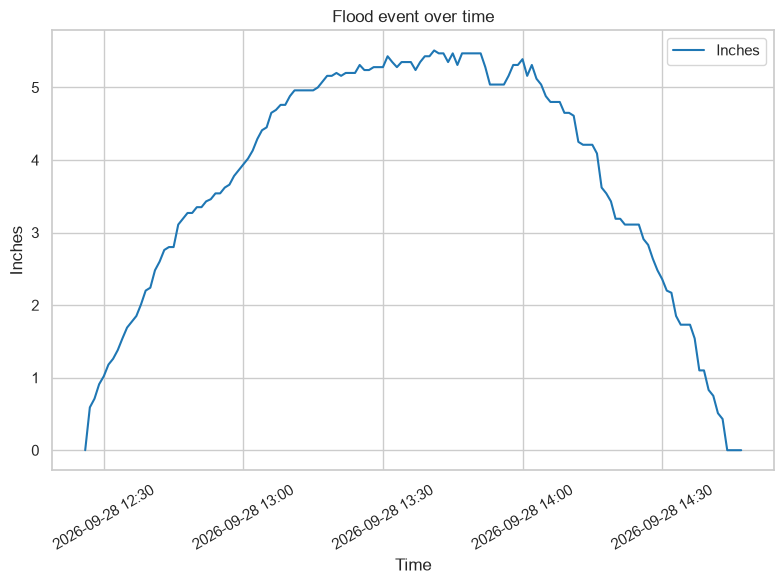

In [615]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.title("Flood event over time")
sns.lineplot(data=resampled_latest_flood_event_time_series_df, ax=ax)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax.tick_params(axis='x', rotation=30)
plt.xlabel("Time")
plt.ylabel("Inches")
plt.tight_layout()
plt.show()

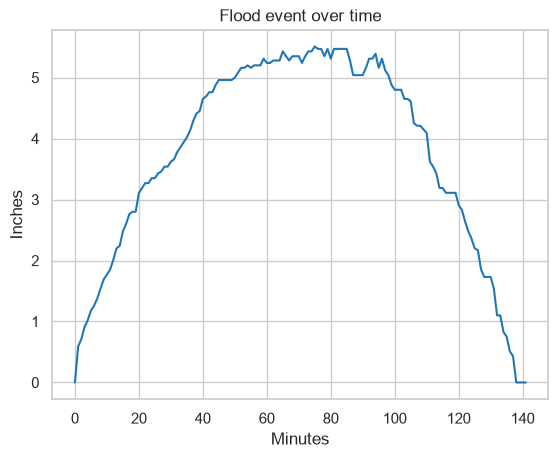

In [616]:
plt.figure()
plt.title("Flood event over time")
sns.lineplot(x=latest_flood_event['Time Series Depth Timestamps (seconds)'] / 60, y=latest_flood_event['Time Series Depth Values (inches)'])
plt.xlabel("Minutes")
plt.ylabel("Inches")
plt.show()